In [ ]:
# 💧 Water Potability Prediction Project

This notebook explores the water potability dataset and applies machine learning models with data augmentation.  
Tasks:
1. Understand dataset
2. Apply augmentation (SMOTE variants)
3. Train models (Decision Tree, SVM, Random Forest, Logistic Regression, Neural Network)
4. Evaluate with multiple metrics
5. Build a Streamlit interface for deployment


In [ ]:
Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Augmentation methods
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTEENN, SMOTETomek

# Neural Network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [2]:
data = pd.read_csv("water_potability.csv")
print("Dataset shape:", data.shape)
data.head()


Dataset shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
print("Missing values per column:")
print(data.isnull().sum())


Missing values per column:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In [18]:
methods = {
    "SMOTE": SMOTE(),
    "Borderline-SMOTE": BorderlineSMOTE(),
    "SMOTEENN": SMOTEENN(),
    "SMOTETomek": SMOTETomek()
}

augmented_data = {}
for name, method in methods.items():
    X_res, y_res = method.fit_resample(X, y)
    augmented_data[name] = (X_res, y_res)
    print(f"{name} applied → Class distribution:\n", pd.Series(y_res).value_counts())


SMOTE applied → Class distribution:
 Potability
0    1998
1    1998
Name: count, dtype: int64
Borderline-SMOTE applied → Class distribution:
 Potability
0    1998
1    1998
Name: count, dtype: int64
SMOTEENN applied → Class distribution:
 Potability
1    939
0    614
Name: count, dtype: int64
SMOTETomek applied → Class distribution:
 Potability
0    1897
1    1897
Name: count, dtype: int64


In [19]:
clf = DecisionTreeClassifier(criterion='entropy', max_depth=12, splitter='best')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Decision Tree Accuracy: 0.6051829268292683
[[319  93]
 [166  78]]
              precision    recall  f1-score   support

           0       0.66      0.77      0.71       412
           1       0.46      0.32      0.38       244

    accuracy                           0.61       656
   macro avg       0.56      0.55      0.54       656
weighted avg       0.58      0.61      0.59       656



In [8]:
clf = DecisionTreeClassifier(criterion='entropy', max_depth=3, splitter='best')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Train accuracy:", round(clf.score(X_train, y_train)*100,2))
print("Test accuracy:", round(accuracy_score(y_test, y_pred)*100,2))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Train accuracy: 63.85
Test accuracy: 63.87
Confusion Matrix:
 [[370  42]
 [195  49]]
Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.90      0.76       412
           1       0.54      0.20      0.29       244

    accuracy                           0.64       656
   macro avg       0.60      0.55      0.52       656
weighted avg       0.61      0.64      0.58       656



In [ ]:
SVM

In [14]:
rf = RandomForestClassifier(n_estimators=150, criterion='entropy', max_depth=10)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("Classification Report:\n", classification_report(y_test, rf_pred))
print("Accuracy:", accuracy_score(y_test, rf_pred)*100)


Confusion Matrix:
 [[390  22]
 [184  60]]
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.95      0.79       412
           1       0.73      0.25      0.37       244

    accuracy                           0.69       656
   macro avg       0.71      0.60      0.58       656
weighted avg       0.70      0.69      0.63       656

Accuracy: 68.59756097560977


In [ ]:
SVM

In [15]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, svm_pred))
print("Classification Report:\n", classification_report(y_test, svm_pred))
print("Accuracy:", accuracy_score(y_test, svm_pred)*100)


Confusion Matrix:
 [[377  35]
 [165  79]]
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.92      0.79       412
           1       0.69      0.32      0.44       244

    accuracy                           0.70       656
   macro avg       0.69      0.62      0.62       656
weighted avg       0.69      0.70      0.66       656

Accuracy: 69.51219512195121


In [ ]:
Logistic Regression

In [16]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, logreg_pred))
print("Classification Report:\n", classification_report(y_test, logreg_pred))
print("Accuracy:", accuracy_score(y_test, logreg_pred)*100)


Confusion Matrix:
 [[412   0]
 [244   0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.63      1.00      0.77       412
           1       0.00      0.00      0.00       244

    accuracy                           0.63       656
   macro avg       0.31      0.50      0.39       656
weighted avg       0.39      0.63      0.48       656

Accuracy: 62.80487804878049


C:\Users\MILOUDI Melouka\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\MILOUDI Melouka\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\MILOUDI Melouka\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [ ]:
NN

In [17]:
nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

nn_pred = (nn.predict(X_test) > 0.5).astype("int32")

print("Confusion Matrix:\n", confusion_matrix(y_test, nn_pred))
print("Classification Report:\n", classification_report(y_test, nn_pred))
print("Accuracy:", accuracy_score(y_test, nn_pred)*100)


C:\Users\MILOUDI Melouka\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Confusion Matrix:
 [[365  47]
 [158  86]]
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.89      0.78       412
           1       0.65      0.35      0.46       244

    accuracy                           0.69       656
   macro avg       0.67      0.62      0.62       656
weighted avg       0.68      0.69      0.66       656

Accuracy: 68.75


In [ ]:
Roc curve 

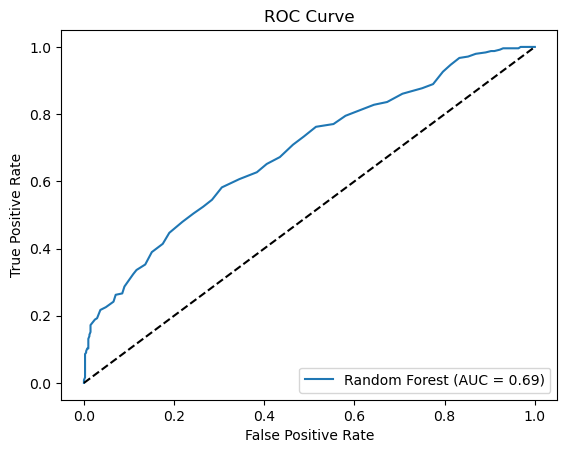

In [13]:
y_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


In [20]:
import joblib
joblib.dump(rf, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']